<center><u><H1>ANN for Classification</H1></u></center>

<img src="images/MLP.png" width="500">

|Code Symbol | Definition | Dimensions
| :-: | :-: | :-: |
|X|Input Data, each row in an example| (num_Samples, inputLayerSize)|
|y |target data|(num_Samples, outputLayerSize)|
|W1 | Layer 1 weights | (inputLayerSize, hiddenLayerSize) |
|W2 | Layer 2 weights | (hiddenLayerSize, outputLayerSize) |
|z_h | Hidden Layer activation | (num_Samples, hiddenLayerSize) |
|a_h | Hidden Layer activity | (num_Samples, hiddenLayerSize) |
|z_out | Output Layer activation | (num_Samples, outputLayerSize) |
|y_hat | Predicted values | (num_Samples, outputLayerSize) |

## Forward Propagation:

### <center> z_h = $XW^{(1)}$ </center>

### <center> a_h = $f$(z_h)</center> 

### <center> z_out = a_h $W^{(2)}$ </center>

### <center> $\hat{y}$ = $f$(z_out) </center>

## Cost Function:

## <center> C = $-\frac{1}{n}$$\sum\limits_{i=1}^{n}$$[y_i\log(\hat{y_i})+(1-{y_i})\log(1-\hat{y_i})]$ </center>

## Backpropagation:

## <center>$\delta_{out} = \hat{y} - y$ </center>

### <center>$\delta_{hidden} = dot(\delta_{out}, W_2^T) * [(a\_h)*(1 - a\_h)]$ </center>

### <center>$\frac{dC}{{dW^1}} = grad\_w\_h = dot(X^T, \delta_{hidden})$ </center>

### <center>$\frac{dC}{db_{hidden}} = grad\_b\_h = \sum(\delta_{hidden})$ </center>

### <center>$\frac{dC}{dW^2} = grad\_w\_out = dot(a\_h^T, \delta_{out})$ </center>

### <center>$\frac{dC}{db_{out}} = grad\_b\_out = \sum(\delta_{out})$ </center>

### <center>$w\_h ~~ -= \lambda * grad\_w\_h$ </center>

### <center>$b\_h ~~ -= \lambda * grad\_b\_h$ </center>

### <center>$w\_out ~~ -= \lambda * grad\_w\_out$ </center>

### <center>$b\_out ~~ -= \lambda * grad\_b\_out$ </center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
%matplotlib inline

## Creating a class for a Neural Network

In [2]:
class Neural_Network(object):
    def __init__(self):        
    #Hyperparameters
        self.random = np.random.RandomState(2018)        
        self.hiddenLayerSize = 100
        self.epochs = 10000
        self.minibatches = 1
        self.learning_rate = 0.01
        self.Lambda = 0.001 #regularization parameter   
            
    ## Preprocessing data:
    
    def onehot(self, y, n_classes):
        onehot = np.zeros((n_classes, y.shape[0]))
        for i, val in enumerate(y.astype(int)):
            onehot[val, i] = 1
        return onehot.T   
    
    def minmaxScaler(self, X_train,X_test):
        scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)
        return X_train_std, X_test_std

    ## Activation Functions and Derivatives:

    def sigmoid(self, x):
        return 1/(1+np.exp(-x))

    def sigmoidPrime(self,z):
        return z * (1 - z)
        
    ## Forward Propagation:

    def forward(self, X):
        z_h = np.dot(X, self.W1) + self.b_h
        a_h = self.sigmoid(z_h)
        z_out = np.dot(a_h, self.W2) + self.b_out
        a_out = self.sigmoid(z_out)
        return z_h, a_h, z_out, a_out

    def predict(self, X):
        z_hidden, a_hidden, z_out, a_out = self.forward(X)
        y_pred = np.argmax(a_out, axis=1)
        return y_pred
    
    ## Cost Function:

    def costFunction(self, y_target, y_hat):
        l2 = (self.Lambda * (np.sum(self.W1**2) + np.sum(self.W2**2)))
        c1 = -y_target * (np.log(y_hat + 1e-8))
        c2 = (1.-y_target)*np.log(1.-y_hat + 1e-8)
        cost = np.sum(c1-c2) + l2
        return cost
       
    def fit(self, X_train, y_train, X_test, y_test):
        n_classes = np.unique(y_train).shape[0]
        n_features = X_train.shape[1]
        
        #Preprocessing the data
        y_train_enc = self.onehot(y_train, n_classes)
        y_test_enc = self.onehot(y_test, n_classes)
        
        X_train, X_test = self.minmaxScaler(X_train, X_test)
        
        #Weights (parameters)
        self.b_h = np.zeros(self.hiddenLayerSize)
        self.W1 = self.random.normal(loc=0.0, scale=0.1,
                                    size=(n_features, self.hiddenLayerSize))
        self.b_out = np.zeros(n_classes)
        self.W2 = self.random.normal(loc=0.0, scale=0.1,
                                    size=(self.hiddenLayerSize, n_classes))
                    
        self.eval = {'cost_train': [], 'cost_test': [], 'train_acc': [], 'test_acc':[]}
        
        for i in range(self.epochs):
            
            batch = np.array_split(range(y_test.shape[0]), self.minibatches)
            
            for idx in batch:
                #forward propagation
                z_h, a_h, z_out, a_out = self.forward(X_train[idx])
                    
                #Backpropagation
                sigma_out = (a_out - y_train_enc[idx])             
                sigma_h = np.dot(sigma_out, self.W2.T) * self.sigmoidPrime(a_h)
                
                grad_W1 = np.dot(X_train[idx].T, sigma_h)
                grad_b_h = np.sum(sigma_h, axis=0)
                
                grad_W2 = np.dot(a_h.T, sigma_out)
                grad_b_out = np.sum(sigma_out, axis=0)
                
                #Regularization and weight updates
                
                delta_W1 = grad_W1 + self.Lambda * self.W1
                delta_b_h = grad_b_h # we dont need to regularize the bias
                self.W1 -= self.learning_rate * delta_W1
                self.b_h -= self.learning_rate * delta_b_h
                
                delta_W2 = grad_W2 + self.Lambda * self.W2
                delta_b_out = grad_b_out
                self.W2 -= self.learning_rate * delta_W2
                self.b_out -= self.learning_rate * delta_b_out
                
            #Evaluation
            z_h, a_h, z_out, a_out_train = self.forward(X_train)
            z_h_test, a_h_test, z_out_test, a_out_test = self.forward(X_test)
            
            cost_train = self.costFunction(y_train_enc, a_out_train)
            cost_test = self.costFunction(y_test_enc, a_out_test)
            
            y_train_pred = self.predict(X_train)
            y_test_pred = self.predict(X_test)
            
            train_acc = (np.sum(y_train == y_train_pred)).astype(float) / X_train.shape[0]
            test_acc = (np.sum(y_test == y_test_pred)).astype(float) / X_test.shape[0]
            
            self.eval['cost_train'].append(cost_train)
            self.eval['cost_test'].append(cost_test)
            self.eval['train_acc'].append(train_acc)
            self.eval['test_acc'].append(test_acc)
            
            if i % 1000 == 0:
                print('training-acc: %.2f' % train_acc)
                print('test-acc: %.2f' % test_acc)
                
        print("Confusion_matrix: \n", confusion_matrix(y_test, y_test_pred))
        print("Classification_report: \n", classification_report(y_test, y_test_pred))      
    
        return self.eval

    ## Plotting Cost Functions for training and testing:     
    def plot(self, cost_train, cost_test, train_acc, test_acc):
        fig, ax = plt.subplots(2, 1, figsize=(10,8))
        ax[0].plot(np.arange(len(cost_train)), cost_train, lw=2, color='blue', label='CostTraining')
        ax[0].plot(np.arange(len(cost_test)), cost_test, lw=2, color='red', label='CostTest')
        ax[0].legend(loc='best')
        ax[0].set_ylabel('Cost')
        ax[0].set_xlabel('Cycles')
        
        ax[1].plot(np.arange(len(train_acc)), train_acc, lw=2, color='blue', label='Training Accuracy %')
        ax[1].plot(np.arange(len(test_acc)), test_acc, lw=2, color='red', label='Test Accuracy %')
        ax[1].legend(loc='best')
        ax[1].set_ylabel('Accuracy')
        ax[1].set_xlabel('Cycles')
        return plt.show()

## Testing the model:

In [3]:
NN = Neural_Network()

In [4]:
iris = load_iris()
X=iris.data
y=iris.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2018)

In [6]:
eval = NN.fit(X_train, y_train, X_test, y_test)

training-acc: 0.37
test-acc: 0.24
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
training-acc: 0.97
test-acc: 0.98
Confusion_matrix: 
 [[18  0  0]
 [ 0 11  0]
 [ 0  1 15]]
Classification_report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.92      1.00      0.96        11
           2       1.00      0.94      0.97        16

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



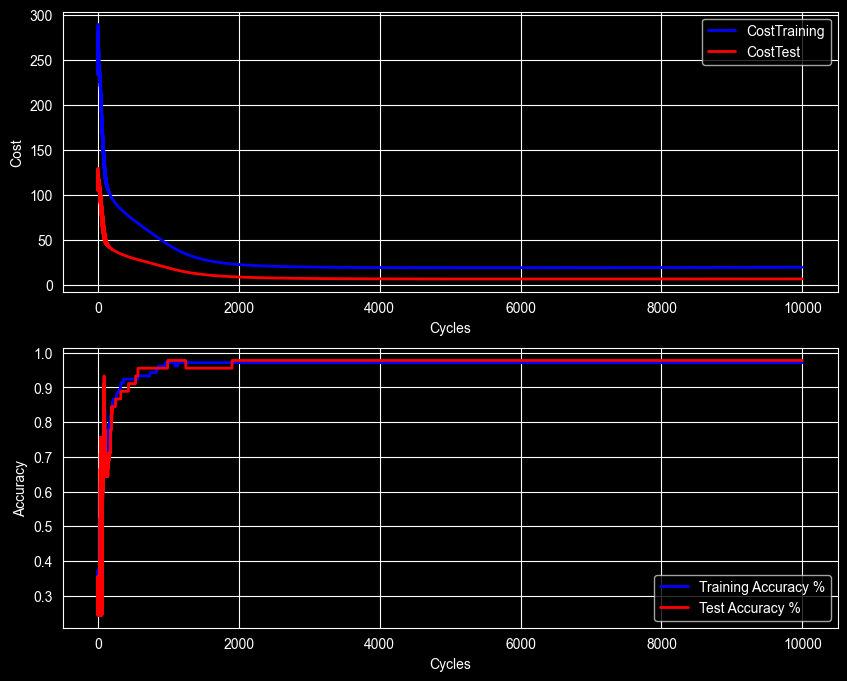

In [7]:
NN.plot(eval['cost_train'], eval['cost_test'], eval['train_acc'], eval['test_acc'] )